# 02 - Treino DNN (NumPy)

DNN implementada de raiz em NumPy com vectorizadores clássicos e forenses.

- **Dataset**: `data/processed/dataset_combined.csv`
- **Validações**: `dataset-exemplos.csv` e `subm1_labels_revealed.csv`
- **Método**: Random search com `build_random_search` de `src/hyperopt.py`


In [1]:
import sys
import os
sys.path.append(os.path.abspath('..'))


In [2]:
import random
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, auc, classification_report, confusion_matrix, roc_curve
from sklearn.preprocessing import label_binarize

from src.data_processing import clean_text
from src.hyperopt import build_random_search
from src.models_numpy.dnn import (
    AdamOptimizer,
    BatchNormalizationLayer,
    CategoricalCrossEntropy,
    Dataset,
    DenseLayer,
    DropoutLayer,
    NeuralNetwork,
    ReLUActivation,
    SoftmaxActivation,
    accuracy,
)
from src.vectorizer import create_vectorizer


In [3]:
# Configuração
SEED = 42
N_ITERATIONS = 20

random.seed(SEED)
np.random.seed(SEED)


## 1. Carregamento de Dados

In [4]:
# Constantes
ROOT = os.path.abspath('..')
CLASSES = ['Anthropic', 'Google', 'Human', 'Meta', 'OpenAI']
LABEL_MAP = {label: i for i, label in enumerate(CLASSES)}
IDX_TO_LABEL = {v: k for k, v in LABEL_MAP.items()}
NUM_CLASSES = len(CLASSES)

TRAIN_PATH = os.path.join(ROOT, 'data', 'processed', 'dataset_combined.csv')
VAL1_PATH = os.path.join(ROOT, 'data', 'validation', 'dataset-exemplos.csv')
VAL2_PATH = os.path.join(ROOT, 'data', 'validation', 'subm1_labels_revealed.csv')

print(f'Classes: {LABEL_MAP}')


def load_data(path):
    df = pd.read_csv(path, sep=';')
    df = df[df['Label'].isin(CLASSES)].copy()
    df['label_id'] = df['Label'].map(LABEL_MAP)
    df['text_clean'] = df['Text'].apply(clean_text)
    return df


def one_hot(labels, n_classes=NUM_CLASSES):
    oh = np.zeros((len(labels), n_classes))
    for i, label in enumerate(labels):
        oh[i, label] = 1
    return oh


df_train = load_data(TRAIN_PATH)
df_val1 = load_data(VAL1_PATH)
df_val2 = load_data(VAL2_PATH)

print(f'Train: {len(df_train)} amostras')
print(f'  Labels: {df_train["Label"].value_counts().to_dict()}')
print(f'Val1 (exemplos): {len(df_val1)} amostras')
print(f'Val2 (subm1): {len(df_val2)} amostras')


Classes: {'Anthropic': 0, 'Google': 1, 'Human': 2, 'Meta': 3, 'OpenAI': 4}
Train: 2566 amostras
  Labels: {'Human': 567, 'Meta': 555, 'Google': 525, 'Anthropic': 488, 'OpenAI': 431}
Val1 (exemplos): 125 amostras
Val2 (subm1): 100 amostras


## 2. Espaço de Busca

In [5]:
param_grid = {
    'vectorizer_type': ['forensic', 'stylometric', 'stylometric_only'],
    'max_words': [500, 1000, 2000],
    'hidden_layers': [[128, 64], [256, 128], [128, 64, 32], [64, 32]],
    'dropout': [0.3, 0.4, 0.5],
    'lr': [0.001, 0.005, 0.01],
    'batch_size': [32, 64, 128],
    'use_batchnorm': [True, False],
    'epochs': [100],
}

print('Opções por parâmetro:')
for k, v in param_grid.items():
    print(f'  {k}: {len(v)} opções')


Opções por parâmetro:
  vectorizer_type: 3 opções
  max_words: 3 opções
  hidden_layers: 4 opções
  dropout: 3 opções
  lr: 3 opções
  batch_size: 3 opções
  use_batchnorm: 2 opções
  epochs: 1 opções


## 3. Funções de Treino

In [6]:
def train_dnn(params, X_train, y_train_oh, X_val, y_val_oh, num_classes):
    opt = AdamOptimizer(learning_rate=params['lr'])

    model = NeuralNetwork(
        epochs=params['epochs'],
        batch_size=params['batch_size'],
        optimizer=opt,
        loss=CategoricalCrossEntropy,
        metric=accuracy,
        early_stopping=True,
        patience=15,
        verbose=False,
    )

    prev_dim = X_train.shape[1]
    for h in params['hidden_layers']:
        model.add(DenseLayer(h, prev_dim))
        if params['use_batchnorm']:
            model.add(BatchNormalizationLayer())
        model.add(ReLUActivation())
        if params['dropout'] > 0:
            model.add(DropoutLayer(params['dropout']))
        prev_dim = h

    model.add(DenseLayer(num_classes, prev_dim))
    model.add(SoftmaxActivation())

    ds_train = Dataset(X_train, y_train_oh)
    ds_val = Dataset(X_val, y_val_oh)

    t0 = time.time()
    history = model.fit(ds_train, ds_val)
    train_time = time.time() - t0

    val_acc = max(history.get('val_acc', [0]))
    train_acc = max(history.get('train_acc', [0]))
    return model, val_acc, train_acc, history, train_time


def evaluate_external(model, vectorizer, df_ext, needs_raw):
    texts_clean = list(df_ext['text_clean'])
    labels = df_ext['label_id'].values

    if needs_raw:
        X = vectorizer.transform(texts_clean, list(df_ext['Text']))
    else:
        X = vectorizer.transform(texts_clean)

    y_oh = one_hot(labels)
    preds_probs = model.predict(Dataset(X, y_oh))
    return accuracy(y_oh, preds_probs)


def full_evaluation(model, vec, df_ext, name, needs_raw):
    texts_clean = list(df_ext['text_clean'])
    labels = df_ext['label_id'].values

    if needs_raw:
        X = vec.transform(texts_clean, list(df_ext['Text']))
    else:
        X = vec.transform(texts_clean)

    y_oh = one_hot(labels)
    preds_probs = model.predict(Dataset(X, y_oh))
    preds = np.argmax(preds_probs, axis=1)
    acc = accuracy_score(labels, preds)

    print(f'\n=== {name} ===')
    print(f'Accuracy: {acc:.4f}')
    print()
    print(classification_report(labels, preds, target_names=CLASSES, zero_division=0))

    fig, ax = plt.subplots(figsize=(8, 6))
    cm = confusion_matrix(labels, preds)
    im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
    ax.figure.colorbar(im, ax=ax)
    ax.set(
        xticks=np.arange(NUM_CLASSES),
        yticks=np.arange(NUM_CLASSES),
        xticklabels=CLASSES,
        yticklabels=CLASSES,
        ylabel='Real',
        xlabel='Previsto',
        title=f'Matriz de Confusão — {name}',
    )
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            ax.text(
                j, i, format(cm[i, j], 'd'), ha='center', va='center',
                color='white' if cm[i, j] > cm.max() / 2 else 'black'
            )

    plt.tight_layout()
    plt.show()
    return preds_probs, labels


## 4. Random Search

In [7]:
results = []
best_internal_val = -1
best_model = None
best_vectorizer = None
best_params = None

print(f'=== Random Search: DNN (NumPy) — {N_ITERATIONS} iterações ===')
print()

for i, params in enumerate(build_random_search(param_grid, n_iter=N_ITERATIONS, random_state=SEED), start=1):
    vtype = params['vectorizer_type']
    print(
        f'[{i}/{N_ITERATIONS}] {vtype} | hidden={params["hidden_layers"]} '
        f'dropout={params["dropout"]} lr={params["lr"]} bs={params["batch_size"]}'
    )

    try:
        needs_raw = vtype in ['forensic', 'stylometric', 'stylometric_only']
        vec = create_vectorizer(vtype, max_words=params['max_words'])

        t0 = time.time()
        if needs_raw:
            X_all = vec.fit_transform(list(df_train['text_clean']), list(df_train['Text']))
        else:
            X_all = vec.fit_transform(list(df_train['text_clean']))
        vec_time = time.time() - t0

        y_all = df_train['label_id'].values
        y_all_oh = one_hot(y_all)

        rng = np.random.default_rng(SEED)
        indices = np.arange(len(y_all))
        train_idx = []
        val_idx = []
        for label in np.unique(y_all):
            cls_idx = indices[y_all == label]
            cls_idx = rng.permutation(cls_idx)
            split = int(0.8 * len(cls_idx))
            train_idx.extend(cls_idx[:split])
            val_idx.extend(cls_idx[split:])
        train_idx = np.array(train_idx)
        val_idx = np.array(val_idx)

        X_tr, X_te = X_all[train_idx], X_all[val_idx]
        y_tr, y_te = y_all_oh[train_idx], y_all_oh[val_idx]

        model, val_acc, train_acc, history, train_time = train_dnn(params, X_tr, y_tr, X_te, y_te, NUM_CLASSES)
        val1_acc = evaluate_external(model, vec, df_val1, needs_raw)
        val2_acc = evaluate_external(model, vec, df_val2, needs_raw)

        print(f'  -> internal={val_acc:.4f} | val1={val1_acc:.4f} | val2={val2_acc:.4f} ({train_time:.1f}s)')

        results.append({
            'iteration': i,
            'vectorizer': vtype,
            'hidden_layers': str(params['hidden_layers']),
            'dropout': params['dropout'],
            'lr': params['lr'],
            'batch_size': params['batch_size'],
            'use_batchnorm': params['use_batchnorm'],
            'max_words': params['max_words'],
            'internal_val': val_acc,
            'train_acc': train_acc,
            'val1_acc': val1_acc,
            'val2_acc': val2_acc,
            'train_time': train_time,
            'vec_time': vec_time,
        })

        if val_acc > best_internal_val:
            best_internal_val = val_acc
            best_model = model
            best_vectorizer = vec
            best_params = params.copy()
            print('  *** NOVO MELHOR INTERNO ***')

    except Exception as e:
        print(f'  -> ERRO: {e}')
        results.append({'iteration': i, 'vectorizer': vtype, 'error': str(e)})

print('\n=== Concluído ===')


=== Random Search: DNN (NumPy) — 20 iterações ===

[1/20] stylometric_only | hidden=[128, 64] dropout=0.5 lr=0.005 bs=32
  -> internal=0.8583 | val1=0.3760 | val2=0.4800 (6.6s)
  *** NOVO MELHOR INTERNO ***
[2/20] stylometric_only | hidden=[128, 64] dropout=0.5 lr=0.005 bs=32
  -> internal=0.8602 | val1=0.3600 | val2=0.5400 (3.3s)
  *** NOVO MELHOR INTERNO ***
[3/20] forensic | hidden=[128, 64] dropout=0.5 lr=0.001 bs=128
  -> internal=0.9068 | val1=0.4240 | val2=0.5400 (61.3s)
  *** NOVO MELHOR INTERNO ***
[4/20] stylometric | hidden=[128, 64, 32] dropout=0.3 lr=0.001 bs=128
  -> internal=0.8602 | val1=0.3600 | val2=0.4300 (103.0s)
[5/20] stylometric | hidden=[256, 128] dropout=0.4 lr=0.001 bs=32
  -> internal=0.8680 | val1=0.3840 | val2=0.5300 (87.7s)
[6/20] stylometric | hidden=[128, 64, 32] dropout=0.3 lr=0.01 bs=64
  -> internal=0.8680 | val1=0.3840 | val2=0.5200 (12.7s)
[7/20] forensic | hidden=[128, 64, 32] dropout=0.5 lr=0.01 bs=64
  -> internal=0.9068 | val1=0.4480 | val2=0.56

## 5. Resultados

In [8]:
results_df = pd.DataFrame(results)
if 'error' in results_df.columns:
    results_df = results_df[results_df['error'].isna()]
results_df = results_df.sort_values('internal_val', ascending=False).reset_index(drop=True)

print('=== Top 5 Modelos (por internal_val) ===')
print(results_df.head(5)[[
    'iteration', 'vectorizer', 'hidden_layers', 'dropout', 'lr',
    'internal_val', 'val1_acc', 'val2_acc'
]].to_string(index=False))


=== Top 5 Modelos (por internal_val) ===
 iteration vectorizer hidden_layers  dropout    lr  internal_val  val1_acc  val2_acc
         8   forensic    [256, 128]      0.4 0.001      0.930097     0.480      0.53
        19   forensic     [128, 64]      0.5 0.010      0.918447     0.448      0.55
        12   forensic     [128, 64]      0.4 0.005      0.916505     0.440      0.53
        14   forensic    [256, 128]      0.3 0.010      0.914563     0.432      0.53
        16   forensic    [256, 128]      0.5 0.001      0.910680     0.448      0.59


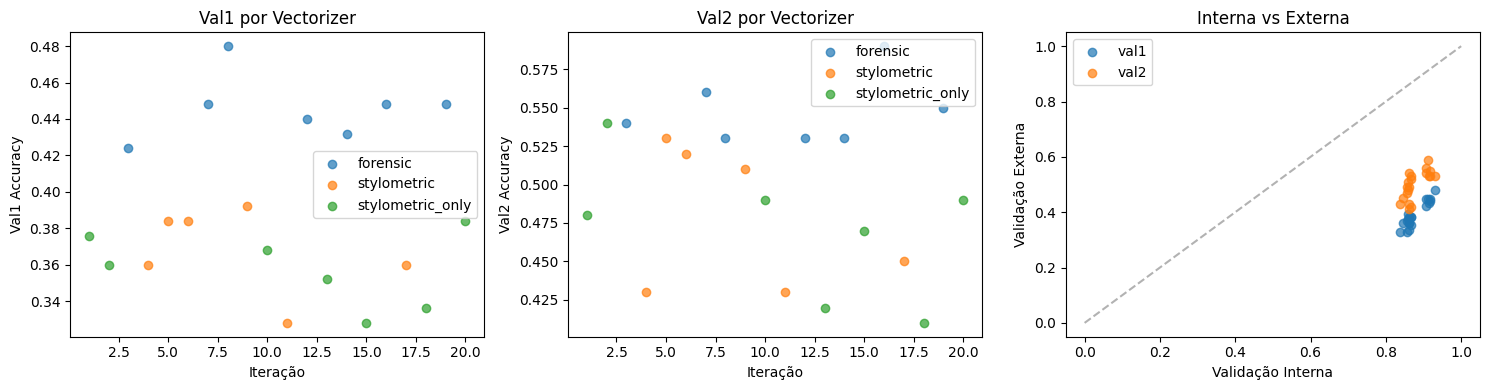

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for vtype in results_df['vectorizer'].unique():
    mask = results_df['vectorizer'] == vtype
    axes[0].scatter(results_df[mask]['iteration'], results_df[mask]['val1_acc'], label=vtype, alpha=0.7)
axes[0].set_xlabel('Iteração')
axes[0].set_ylabel('Val1 Accuracy')
axes[0].set_title('Val1 por Vectorizer')
axes[0].legend()

for vtype in results_df['vectorizer'].unique():
    mask = results_df['vectorizer'] == vtype
    axes[1].scatter(results_df[mask]['iteration'], results_df[mask]['val2_acc'], label=vtype, alpha=0.7)
axes[1].set_xlabel('Iteração')
axes[1].set_ylabel('Val2 Accuracy')
axes[1].set_title('Val2 por Vectorizer')
axes[1].legend()

axes[2].scatter(results_df['internal_val'], results_df['val1_acc'], label='val1', alpha=0.7)
axes[2].scatter(results_df['internal_val'], results_df['val2_acc'], label='val2', alpha=0.7)
axes[2].plot([0, 1], [0, 1], 'k--', alpha=0.3)
axes[2].set_xlabel('Validação Interna')
axes[2].set_ylabel('Validação Externa')
axes[2].set_title('Interna vs Externa')
axes[2].legend()

plt.tight_layout()
plt.show()


## 6. Avaliação Detalhada do Melhor Modelo

In [10]:
print('=== Melhor Modelo DNN ===')
for key, value in best_params.items():
    print(f'{key}: {value}')
print(f'Best Internal Validation Accuracy: {best_internal_val:.4f}')


=== Melhor Modelo DNN ===
vectorizer_type: forensic
max_words: 2000
hidden_layers: [256, 128]
dropout: 0.4
lr: 0.001
batch_size: 32
use_batchnorm: True
epochs: 100
Best Internal Validation Accuracy: 0.9301



=== Val1 (exemplos) ===
Accuracy: 0.4800

              precision    recall  f1-score   support

   Anthropic       0.44      0.30      0.36        23
      Google       0.33      0.44      0.38        16
       Human       0.65      0.69      0.67        52
        Meta       0.40      0.35      0.38        17
      OpenAI       0.22      0.24      0.23        17

    accuracy                           0.48       125
   macro avg       0.41      0.40      0.40       125
weighted avg       0.48      0.48      0.48       125



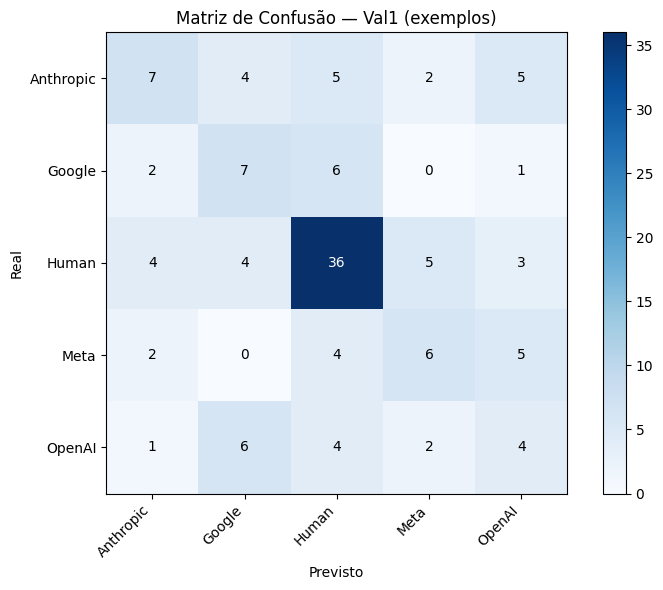


=== Val2 (subm1) ===
Accuracy: 0.5300

              precision    recall  f1-score   support

   Anthropic       0.50      0.35      0.41        17
      Google       0.46      0.65      0.54        17
       Human       0.60      0.62      0.61        34
        Meta       0.83      0.56      0.67        18
      OpenAI       0.29      0.36      0.32        14

    accuracy                           0.53       100
   macro avg       0.54      0.51      0.51       100
weighted avg       0.56      0.53      0.53       100



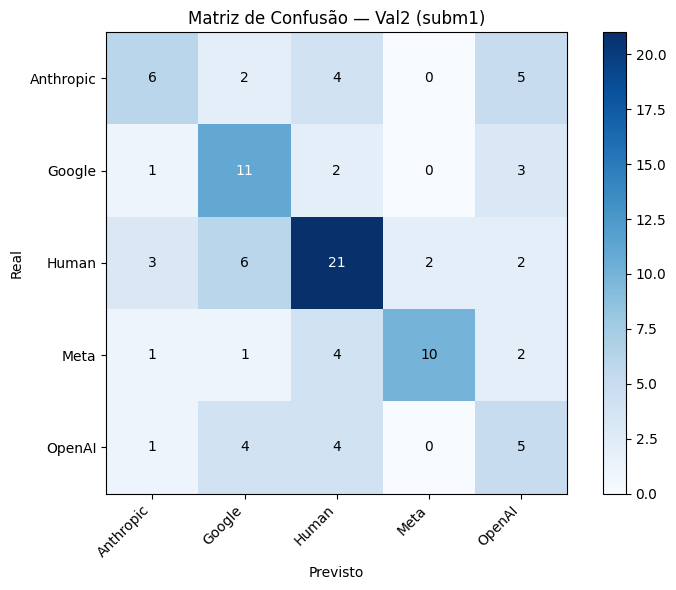

In [11]:
needs_raw = best_params['vectorizer_type'] in ['forensic', 'stylometric', 'stylometric_only']
probs_val1, labels_val1 = full_evaluation(best_model, best_vectorizer, df_val1, 'Val1 (exemplos)', needs_raw)
probs_val2, labels_val2 = full_evaluation(best_model, best_vectorizer, df_val2, 'Val2 (subm1)', needs_raw)


## 7. Curva ROC (Macro Average)

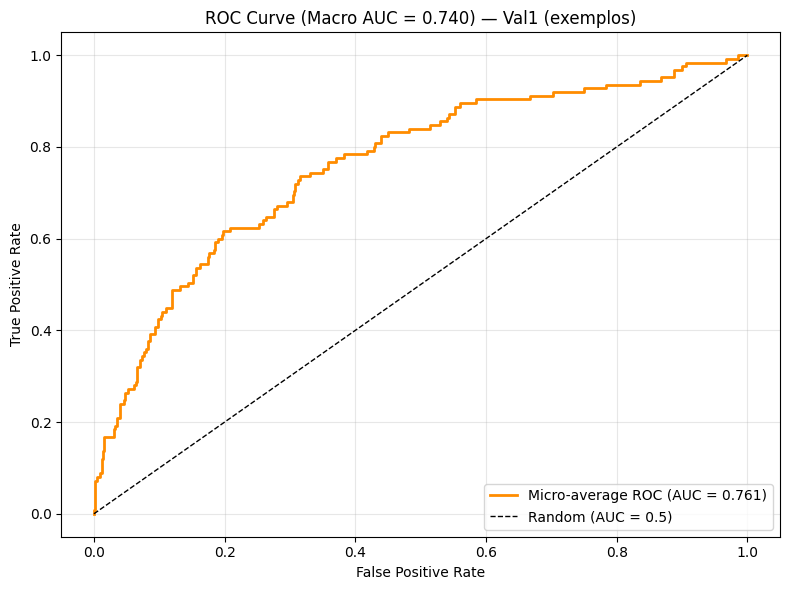

Val1 (exemplos): Micro AUC = 0.7614, Macro AUC = 0.7398


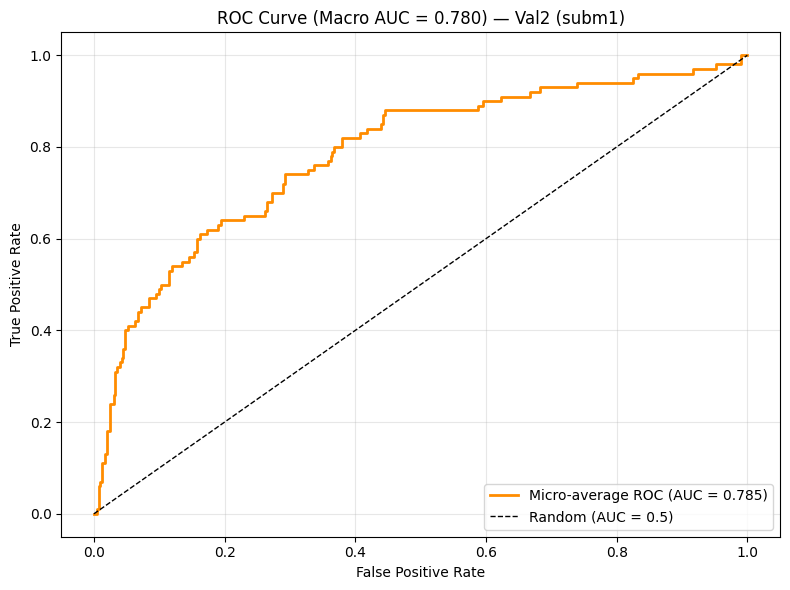

Val2 (subm1): Micro AUC = 0.7851, Macro AUC = 0.7803


In [12]:
def plot_roc_macro(probs, labels, name):
    labels_bin = label_binarize(labels, classes=range(NUM_CLASSES))
    fpr, tpr, _ = roc_curve(labels_bin.ravel(), probs.ravel())
    roc_auc = auc(fpr, tpr)

    aucs = []
    for i in range(NUM_CLASSES):
        fpr_i, tpr_i, _ = roc_curve(labels_bin[:, i], probs[:, i])
        aucs.append(auc(fpr_i, tpr_i))
    macro_auc = np.mean(aucs)

    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Micro-average ROC (AUC = {roc_auc:.3f})')
    plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random (AUC = 0.5)')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve (Macro AUC = {macro_auc:.3f}) — {name}')
    plt.legend(loc='lower right')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    print(f'{name}: Micro AUC = {roc_auc:.4f}, Macro AUC = {macro_auc:.4f}')
    return macro_auc

macro_auc_val1 = plot_roc_macro(probs_val1, labels_val1, 'Val1 (exemplos)')
macro_auc_val2 = plot_roc_macro(probs_val2, labels_val2, 'Val2 (subm1)')


## 8. Conclusões

In [13]:
print('=' * 60)
print('CONCLUSÕES — DNN (NumPy)')
print('=' * 60)
print()

print('Média por vectorizer:')
for vtype in results_df['vectorizer'].unique():
    mask = results_df['vectorizer'] == vtype
    mean_v1 = results_df[mask]['val1_acc'].mean()
    mean_v2 = results_df[mask]['val2_acc'].mean()
    print(f'  {vtype:20s}: val1={mean_v1:.4f} | val2={mean_v2:.4f}')

print() 
print('Melhor configuração:')
for key, value in best_params.items():
    print(f'  {key}: {value}')
print(f'Best Internal Validation Accuracy: {best_internal_val:.4f}')
print(f'Val1 AUC (macro): {macro_auc_val1:.4f}')
print(f'Val2 Accuracy: {results_df.loc[results_df["internal_val"].idxmax(), "val2_acc"]:.4f}')
print(f'Val2 AUC (macro): {macro_auc_val2:.4f}')


CONCLUSÕES — DNN (NumPy)

Média por vectorizer:
  forensic            : val1=0.4457 | val2=0.5471
  stylometric         : val1=0.3680 | val2=0.4783
  stylometric_only    : val1=0.3577 | val2=0.4714

Melhor configuração:
  vectorizer_type: forensic
  max_words: 2000
  hidden_layers: [256, 128]
  dropout: 0.4
  lr: 0.001
  batch_size: 32
  use_batchnorm: True
  epochs: 100
Best Internal Validation Accuracy: 0.9301
Val1 AUC (macro): 0.7398
Val2 Accuracy: 0.5300
Val2 AUC (macro): 0.7803
